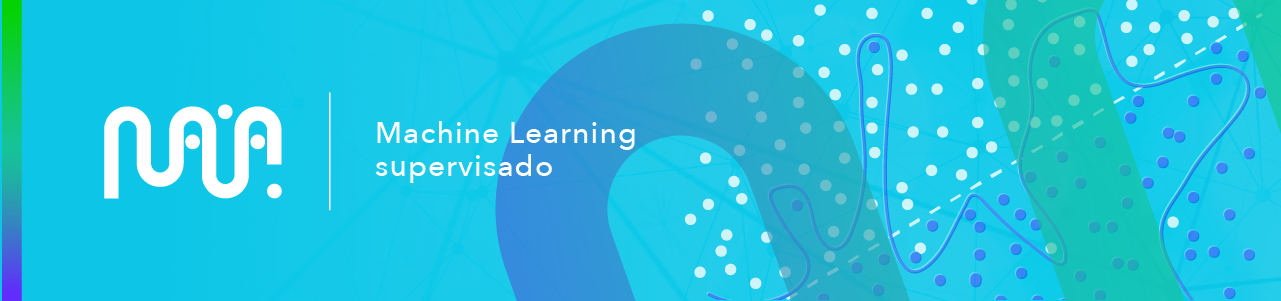
# Taller: Problema de regresión con SVR

***MLS. Machine learning supervisado***
<br>***Semana 5, Taller:*** *SVR*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Mónica Gantiva*



## Introducción
### Descripción
Este *jupyter notebook* contiene el material necesario para el desarrollo del Taller calificable de la Semana 5 del curso *MLS: Machine learning supervisado*. En esta tarea se presentará un problema de regresión que será resuelto aplicando SVR. Usted deberá modificar hiperparámetros del modelo para mejorar su desempeño y analizar los resultados.

#### Objetivos de Aprendizaje
Aplicar modelos basados en kernel para resolver problemas de regresión. 

### Teoría

###  Support Vector Machine (SVM):
En terminos generales una máquina de soporte vectorial (o SVM por sus siglas en inglés) es un modelo de clasificación que busca encontrar el híperplano que separe de mejor manera los datos de dos o varias clases. Esta tarea se puede plantear como un simple problema de optimización con restricciones. En últimas lo que se desea es encontrar la separación óptima de los datos.

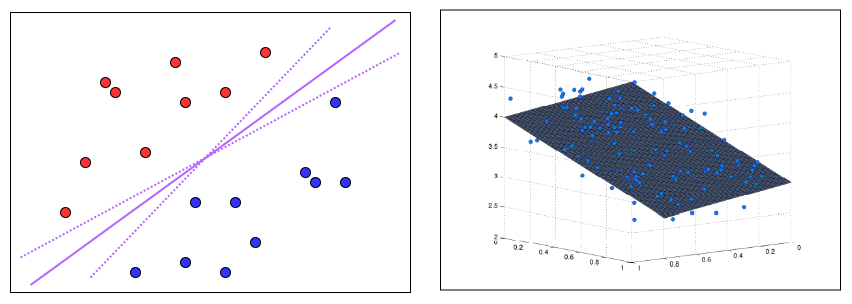

Un Support Vector Machine (SVM) es un algoritmo de aprendizaje supervisado que puede utilizarse tanto para clasificación como para regresión. Cuando se utiliza para regresión, se denomina Support Vector Regression (SVR). Ambos SVM y SVR comparten el mismo principio fundamental, que es encontrar un hiperplano en un espacio de alta dimensión que tenga la máxima distancia a los puntos de datos de las clases o, en el caso de SVR, que tenga la máxima distancia a los puntos de datos en la regresión.

### Support Vector Regression (SVR):

**Objetivo de la Regresión:**

A diferencia de la clasificación, donde el objetivo es encontrar un hiperplano que separe las clases, en la regresión (SVR), el objetivo es encontrar un hiperplano que maximice la cantidad de puntos de datos (muestras) que están dentro de un margen (llamado "margen insensitivo") alrededor de la línea de regresión.

**Margen Insensitivo:**
En SVR, se permite que algunos puntos estén dentro del margen insensitivo o incluso en el lado incorrecto del hiperplano, pero se penalizan según cuán lejos estén de la predicción.

**Kernel Trick:**
Similar a SVM, SVR puede hacer uso del "kernel trick". El kernel transforma los datos de entrada a un espacio de mayor dimensión, permitiendo a SVR manejar relaciones no lineales entre características.

**Parámetros:**
Algunos de los parámetros clave de SVR incluyen el tipo de kernel (lineal, RBF, polinómico, etc.), el parámetro de regularización C, y otros específicos del kernel (como el coeficiente gamma para el kernel RBF).

### Metodología
En este taller se abordará un poblema aplicado de regresión para el cual usted deberá tomar el modelo de SVR y mejorar su desempeño. Para ello emplee las celdas que tienen la siguiente notación.


In [1]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Así mismo, usted deberá análizar los resultados obtenidos para cada modelo. Para ello, responda las preguntas que se presentarán durante el taller. Dispondra de celdas con la siguiente notación para escribir su análisis:


***Respuesta:***

### Problema aplicado: Predicción del precios de casas en Boston

#### Inicialización

In [1]:
import pandas as pd
import numpy as np 
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

In [2]:
import pandas as pd
import numpy as np 
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#### Cargamos los datos

In [3]:
boston = load_boston()

# DataFrame de Características
data = pd.DataFrame(data=boston['data'], columns=boston['feature_names'])
data.head(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


Esta base de datos proviene del conjunto de datos Boston Housing Prices y contiene información de precios de viviendas en Boston 

### Separación de datos

In [4]:
X = boston.data  # características
y = boston.target  # etiquetas


# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Ejemplo: SVR
Ahora se muestra un ejemplo de cómo aplicar un SVR para realizar la predicción del precio de las casas en Boston. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene el desempeño del modelo. Se muestra el error de predicción y la gráfica de dispersión de valores reales frente a los valores predichos. 

Mean Squared Error: 44.33500513460085


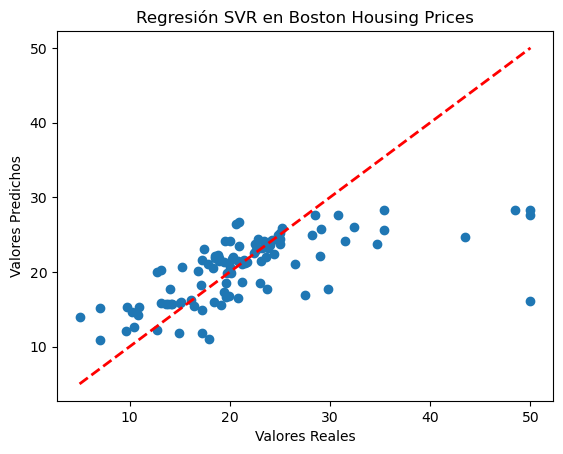

In [8]:
# Creación del modelo SVR
svr = SVR(kernel='rbf', C=10.0, epsilon=0.2)

#Entrenamiento del modelo
svr.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = svr.predict(X_test)

# Evaluar el rendimiento del modelo
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Graficar resultados
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Regresión SVR en Boston Housing Prices')
plt.show()


Tomando como guía el ejemplo anterior, modifique los hiperparámetros del modelo con el propósito de mejorar su desempeño. Recuerde que puede modificar los siguientes parámetros:

**C (parámetro de regularización):** Controla el equilibrio entre un límite suave y un límite ajustado. Valores más altos de C conducen a límites más ajustados.

**epsilon (margen insensitivo):** Especifica la cantidad de error tolerado en la predicción. Valores más altos permiten un mayor error en las predicciones.

**kernel (núcleo):** Puedes experimentar con diferentes funciones de kernel, como 'linear', 'rbf' (radial basis function), 'poly' (polinómico), etc.

Varie estos hiperparámetros de la siguiente manera:

**C** de 0.1 a 10

**epsilon** de 0.1 a 0.5

**kernel**, aplique los kernal:linear, rbf o poly

Pruebe diferentes combinaciones de hiperparámetros y muestre el desempeño del modelo para al menos 4 casos (el error y la gráfica de dispersión de valores reales frente a los valores predichos). *Puede utilizar GridSearchCV*

SVR con Kernel : linear, C : 0.1, epsilon: 0.1 
Mean Squared Error: 24.63659221403535
Grafica:


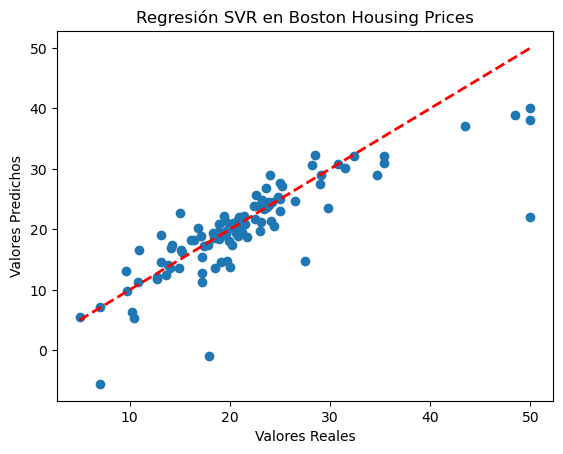

In [9]:
# =====================================================
# COMPLETAR ===========================================
# 
def svr_model(X_train,y_train,X_test,y_test,kernel,C,epsilon):
    '''Funcion que entrena un modelo SVR para diferentes Kernel, C y epsilon.
        Retorna el modelo entrenado, la y_pred y el mse
    '''
    kernel = str(kernel)
    C = float(C)
    epsilon = float(epsilon)
    
    modelo = f'SVR con Kernel : {kernel}, C : {C}, epsilon: {epsilon} '
    # Creación del modelo SVR
    svr = SVR(kernel=kernel, C=C, epsilon=epsilon)

    #Entrenamiento del modelo
    svr.fit(X_train, y_train)

    # Realizar predicciones en el conjunto de prueba
    y_pred = svr.predict(X_test)

    # Evaluar el rendimiento del modelo
    mse = mean_squared_error(y_test, y_pred)
    
    return modelo,y_pred,mse

def visualizacion_svr(y_test,y_pred):
    # Graficar resultados
    plt.scatter(y_test, y_pred)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle='--', color='red', linewidth=2)
    plt.xlabel('Valores Reales')
    plt.ylabel('Valores Predichos')
    plt.title('Regresión SVR en Boston Housing Prices')
    
    return plt.show()
    

def visual_resultado(model_svr,y_pred,mse,y_test):
    print("=====================================================")
    print(model_svr)
    print(f"Mean Squared Error: {mse}")
    print("=====================================================")
    print("Grafica:")
    visualizacion_svr(y_test,y_pred)
    
# 1. C = 0.1 epsilon = 0.1 Kernel = linear
model_svr_lineal_1,y_pred_1,mse_lineal_1 = svr_model(X_train,y_train,X_test,y_test,'linear',0.1,0.1)
visual_resultado(model_svr_lineal_1,y_pred_1,mse_lineal_1,y_test)

# =====================================================

SVR con Kernel : linear, C : 8.0, epsilon: 0.2 
Mean Squared Error: 30.139913841883075
Grafica:


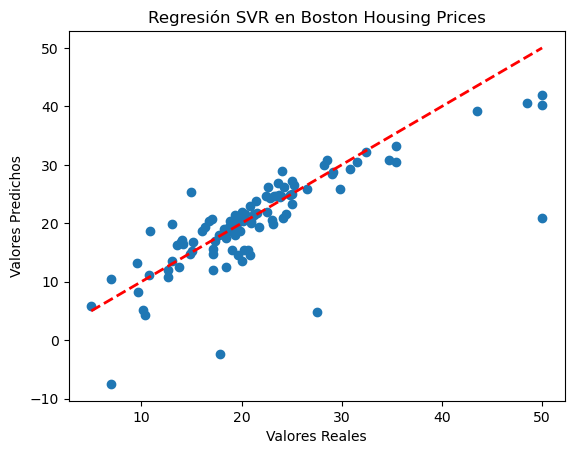

In [11]:
# 1. C = 10 epsilon = 0.2 Kernel = linear
model_svr_lineal_2,y_pred_1,mse_lineal_2 = svr_model(X_train,y_train,X_test,y_test,'linear',8,0.2)
visual_resultado(model_svr_lineal_2,y_pred_1,mse_lineal_2,y_test)

SVR con Kernel : rbf, C : 0.1, epsilon: 0.1 
Mean Squared Error: 61.42615032613023
Grafica:


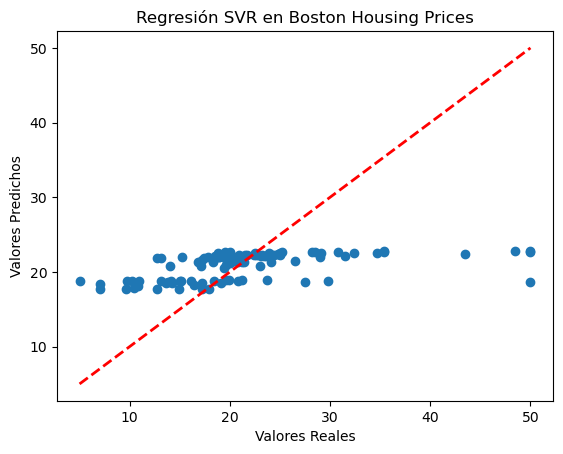

In [10]:
# 2. C = 0.1 epsilon = 0.1 Kernel = rbf
model_svr__rbf_1,y_pred_2,mse_rbf_1 = svr_model(X_train,y_train,X_test,y_test,'rbf',0.1,0.1)
visual_resultado(model_svr__rbf_1,y_pred_2,mse_rbf_1,y_test)

SVR con Kernel : rbf, C : 10.0, epsilon: 0.5 
Mean Squared Error: 44.43293642541932
Grafica:


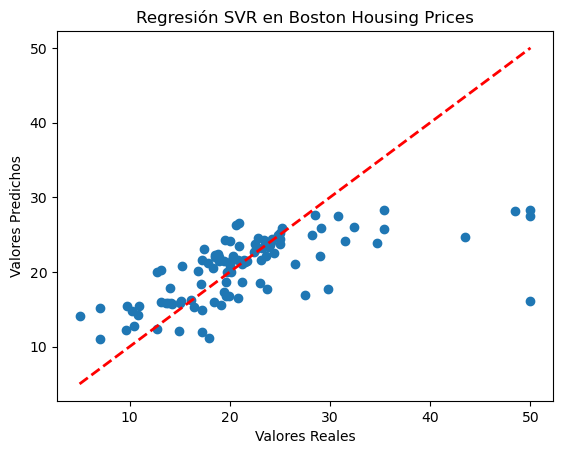

In [12]:
# 3. C = 10 epsilon = 0.5 Kernel = rbf
model_svr_rbf_2,y_pred_2,mse_rbf_2 = svr_model(X_train,y_train,X_test,y_test,'rbf',10,0.5)
visual_resultado(model_svr_rbf_2,y_pred_2,mse_rbf_2,y_test)

SVR con Kernel : poly, C : 10.0, epsilon: 0.5 
Mean Squared Error: 42.28415386113403
Grafica:


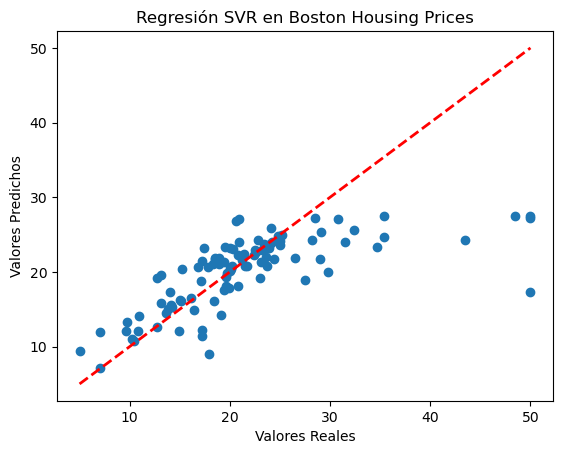

In [13]:
# 4. C = 10 epsilon = 0.5 Kernel = poly
model_svr_poly_1,y_pred_2,mse_poly_1 = svr_model(X_train,y_train,X_test,y_test,'poly',10,0.5)
visual_resultado(model_svr_poly_1,y_pred_2,mse_poly_1,y_test)

SVR con Kernel : poly, C : 0.1, epsilon: 0.1 
Mean Squared Error: 58.792436228281204
Grafica:


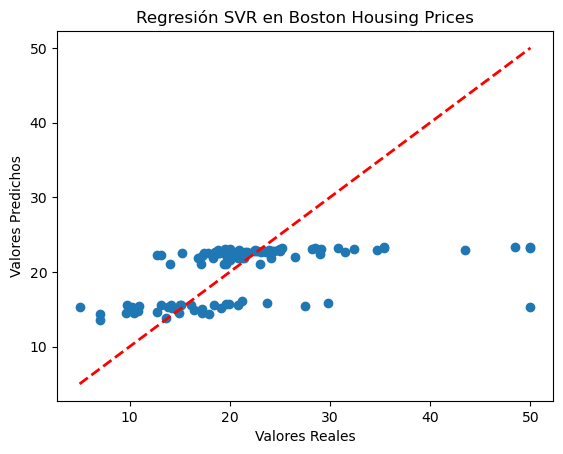

In [14]:
# 4. C = 0.1 epsilon = 0.1 Kernel = poly
model_svr_poly_2,y_pred_2,mse_poly_2 = svr_model(X_train,y_train,X_test,y_test,'poly',0.1,0.1)
visual_resultado(model_svr_poly_2,y_pred_2,mse_poly_2,y_test)

SVR con Kernel : poly, C : 5.0, epsilon: 0.2 
Mean Squared Error: 46.833834301899714
Grafica:


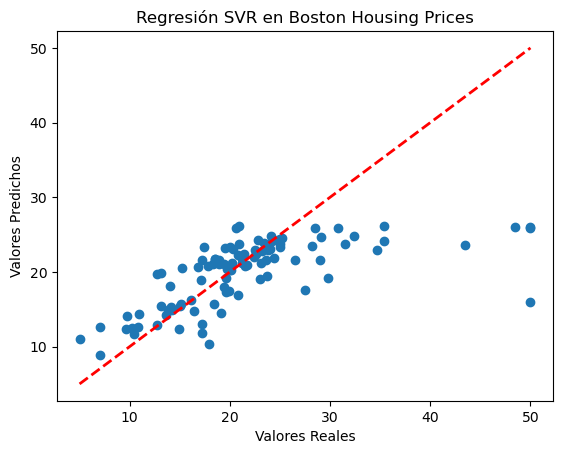

In [15]:
# 4. C = 5 epsilon = 0.2 Kernel = poly
model_svr_2,y_pred_2,mse_2 = svr_model(X_train,y_train,X_test,y_test,'poly',5,0.2)
visual_resultado(model_svr_2,y_pred_2,mse_2,y_test)

In [16]:
# Consolidacion de resultados:
import pandas as pd

modelos = [model_svr_lineal_1,model_svr_lineal_2,model_svr__rbf_1,model_svr_rbf_2,model_svr_poly_1,model_svr_poly_2]
mses = [mse_lineal_1,mse_lineal_2,mse_rbf_1,mse_rbf_2,mse_poly_1,mse_poly_2]

# Crear DataFrame
df_resultados = pd.DataFrame({
    "Modelo": modelos,
    "MSE": mses
})

print(df_resultados)



                                            Modelo        MSE
0  SVR con Kernel : linear, C : 0.1, epsilon: 0.1   24.636592
1  SVR con Kernel : linear, C : 8.0, epsilon: 0.2   30.139914
2     SVR con Kernel : rbf, C : 0.1, epsilon: 0.1   61.426150
3    SVR con Kernel : rbf, C : 10.0, epsilon: 0.5   44.432936
4   SVR con Kernel : poly, C : 10.0, epsilon: 0.5   42.284154
5    SVR con Kernel : poly, C : 0.1, epsilon: 0.1   58.792436


## GridSearchCV

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

# Definir el espacio de búsqueda
param_grid = {
    'C': [0.1, 1, 10],
    'epsilon': [0.1, 0.3, 0.5],
    'kernel': ['linear', 'rbf', 'poly']
}

# Crear el modelo base
svr = SVR()

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,                # validación cruzada con 5 folds
    scoring='neg_mean_squared_error',  # métrica a optimizar
    n_jobs=-1,           # usa todos los núcleos disponibles
    verbose=2
)

# Entrenar búsqueda
grid_search.fit(X_train, y_train)

# Mejor combinación encontrada
print("Mejores hiperparámetros:", grid_search.best_params_)

# Evaluar en test
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MSE en test:", mse)


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros: {'C': 10, 'epsilon': 0.1, 'kernel': 'linear'}
MSE en test: 29.648101739114626


SVR con Kernel : linear, C : 10.0, epsilon: 0.1 
Mean Squared Error: 29.648101739114626
Grafica:


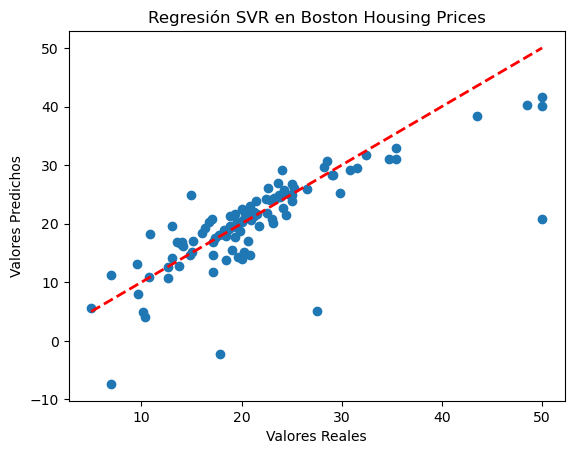

[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, epsilon=0.1, kernel=linear; total time=   0.2s
[CV] END ..................C=0.1, epsilon=0.3, kernel=linear; total time=   0.1s
[CV] END ..................C=0.1, epsilon=0.3, kernel=linear; total time=   0.2s
[CV] END .....................C=0.1, epsilon=0.3, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.3, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.3, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.3, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, epsilon=0.3, kernel=rbf; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.3, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, epsilon=0.3, kernel=poly; total time=   0.0s
[CV] END ...................

In [18]:
model_svr_lineal_1,y_pred_1,mse_lineal_1 = svr_model(X_train,y_train,X_test,y_test,'linear',10,0.1)
visual_resultado(model_svr_lineal_1,y_pred_1,mse_lineal_1,y_test)

Responda la siguientes preguntas:
1. ¿Cómo afecta la variación de estos hiparámetros en el desempeño del modelo? Justifique su respuesta para el C, los diferentes kernel empleado y epsilon
2. ¿Cuál fué el modelo con mejor desempeño? ¿Cómo se refleja esto en la gráfica de dispersión?

***RESPUESTAS***

***¿Cómo afecta la variación de estos hiparámetros en el desempeño del modelo? Justifique su respuesta para el C, los diferentes kernel empleado y epsilon***

***R//***

La variación de los hiperparámetros en SVR afecta directamente el equilibrio entre sesgo y varianza del modelo: un C pequeño (ej. 0.1) implica mayor regularización y modelos más simples que pueden generalizar mejor, mientras que un C grande (ej. 10) reduce la regularización y ajusta más los datos, lo que puede mejorar el desempeño en validación cruzada pero aumentar el error en test

Como vimos con GridSearchCV que eligió linear, C=10, epsilon=0.1 aunque en el conjunto de prueba dio un MSE ≈ 29.64 frente al ≈ 24.63 del modelo con C=0.1; respecto al kernel, el lineal funcionó mejor porque la relación parece ser aproximadamente lineal, mientras que los kernels más complejos como RBF y poly capturan relaciones no lineales pero en este caso generaron mayor error (MSE entre 42 y 61); finalmente, el epsilon controla la tolerancia al error: valores pequeños (0.1) obligan al modelo a ajustarse más a los datos, lo que puede reducir el error en algunos casos pero también aumentar el riesgo de sobreajuste, mientras que valores mayores (0.5) suavizan el modelo y permiten mayor margen de error.

***¿Cuál fué el modelo con mejor desempeño? ¿Cómo se refleja esto en la gráfica de dispersión?***

***R//***

El modelo con mejor desempeño fue el SVR con kernel lineal, C=0.1 y epsilon=0.1, ya que obtuvo el menor error cuadrático medio (MSE ≈ 24.63) frente a todas las demás combinaciones probadas. En la gráfica de dispersión, esto se refleja en que los puntos predichos están más cercanos a la diagonal ideal (línea roja), mostrando que las predicciones se alinean mejor con los valores reales. 

Aunque GridSearchCV sugirió que el modelo lineal con C=10, epsilon=0.1 era más robusto en validación cruzada, en el conjunto de prueba el desempeño fue inferior (MSE ≈ 29.64), confirmando que el dataset en particular la combinación más simple (C=0.1, epsilon=0.1) generaliza mejor.